In [1]:
import hoda
import tensorly as tl
import mne
    
mne.set_log_level('ERROR')
tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import P300, MotorImagery
from moabb.datasets import *
from mne.decoding import Scaler

paradigm = P300(resample=128)
dataset = BNCI2014008()

BNCI2014008 has been renamed to BNCI2014_008. BNCI2014008 will be removed in version 1.1.
The dataset class name 'BNCI2014008' must be an abbreviation of its code 'BNCI2014-008'. See moabb.datasets.base.is_abbrev for more information.


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


In [3]:
from hoda.hoda import HODA

hoda = HODA(
        rank=None,
        max_iter=128,
        tol=1e-12,
        init ='random',
        shrinkage='lw',
        toeplitz=None,
        obj='rt',
        solver='lanczos',
        taper=True,
        extra_train_info=False,
        verbose=True,
        delta=None,
        ortho=False,
        fit_forward=True,
        random_state=42,
)
ranks = [1,2,4,8]

In [4]:
from sklearn.model_selection import StratifiedKFold
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


df = []
for subject in dataset.subject_list[:1]:
    epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[subject],
                                         return_epochs=True)
    for session in meta['session'].unique():
        ses_idc = meta['session'] == session
        X = epochs[ses_idc].get_data()
        X = tl.tensor(X)
        y = labels[ses_idc]

        for fold, (train_idc, test_idc) in enumerate(cv.split(X, y)):
            for r in ranks:
                hoda.set_params(rank=r)
                hoda.fit(X[train_idc], y[train_idc])
                X_train_rec = hoda.inv_transform(hoda.transform(X[train_idc]))
                X_test_rec = hoda.inv_transform(hoda.transform(X[test_idc]))
                mse_train = tl.metrics.regression.MSE(X[train_idc], X_train_rec)
                mse_test = tl.metrics.regression.MSE(X[test_idc], X_test_rec)
                df.append(dict(
                    subject=subject,
                    session=session,
                    fold=fold,
                    rank=r,
                    mse_train=float(mse_train),
                    mse_test=float(mse_test),
                    mse_norm_train=float(mse_train/tl.metrics.regression.MSE(X,0)),
                    mse_norm_test=float(mse_test/tl.metrics.regression.MSE(X,0)),
                ))
            
df = pd.DataFrame(df)

  0%|          | 0/128 [00:00<?, ?it/s]

  0%|          | 0/128 [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/cupy/linalg/_solve.py:169: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


  0%|          | 0/128 [00:00<?, ?it/s]

  0%|          | 0/128 [00:00<?, ?it/s]

...

  0%|          | 0/128 [00:00<?, ?it/s]

  0%|          | 0/128 [00:00<?, ?it/s]

  0%|          | 0/128 [00:00<?, ?it/s]

  0%|          | 0/128 [00:00<?, ?it/s]

  0%|          | 0/128 [00:00<?, ?it/s]

In [5]:
df

,subject,session,fold,rank,mse_train,mse_test,mse_norm_train,mse_norm_test
0,1,0,0,1,1.083885e-10,1.091550e-10,0.997754,1.004810
1,1,0,0,2,1.081619e-10,1.090264e-10,0.995668,1.003626
2,1,0,0,4,1.075024e-10,1.083755e-10,0.989597,0.997635
3,1,0,0,8,9.208489e-11,9.369197e-11,0.847674,0.862467
4,1,0,1,1,1.076938e-10,1.119364e-10,0.991359,1.030414
5,1,0,1,2,1.075258e-10,1.118331e-10,0.989813,1.029463
6,1,0,1,4,1.065459e-10,1.108160e-10,0.980792,1.020100
7,1,0,1,8,9.256813e-11,9.650629e-11,0.852122,0.888374
8,1,0,2,1,1.091950e-10,1.059325e-10,1.005179,0.975146
9,1,0,2,2,1.090438e-10,1.058640e-10,1.003786,0.974516


<Axes: xlabel='rank', ylabel='mse_norm_train'>

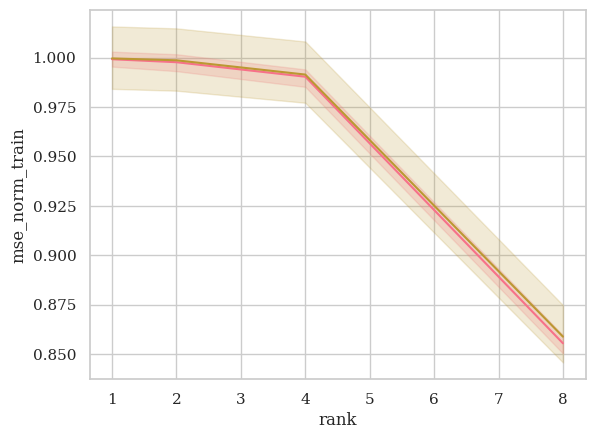

In [6]:
import seaborn as sns
sns.lineplot(data=df, x='rank', y='mse_norm_train')
sns.lineplot(data=df, x='rank', y='mse_norm_test')